In [2]:
#Exploratory data analysis (EDA)
import pandas as pd
data=pd.read_csv("../data/heart.csv")
data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [4]:
data.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [5]:
#Numerical columns 
data['trestbps'] = data['trestbps'].fillna(data['trestbps'].median())
data['chol'] = data['chol'].fillna(data['chol'].median())
data['thalch'] = data['thalch'].fillna(data['thalch'].median())
data['oldpeak'] = data['oldpeak'].fillna(data['oldpeak'].median())

In [6]:
#Categorical columns
data['fbs'] = data['fbs'].fillna(data['fbs'].mode()[0])
data['restecg'] = data['restecg'].fillna(data['restecg'].mode()[0])
data['exang'] = data['exang'].fillna(data['exang'].mode()[0])
data['slope'] = data['slope'].fillna(data['slope'].mode()[0])
data['thal'] = data['thal'].fillna(data['thal'].mode()[0])

/var/folders/63/981_f11x4nz0y_95hkc2qryw0000gn/T/ipykernel_1793/325945229.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['fbs'] = data['fbs'].fillna(data['fbs'].mode()[0])
/var/folders/63/981_f11x4nz0y_95hkc2qryw0000gn/T/ipykernel_1793/325945229.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['exang'] = data['exang'].fillna(data['exang'].mode()[0])


In [7]:
data['ca_missing']=data['ca'].isnull().astype(int)
data['ca']=data['ca'].fillna(0)

In [8]:
data.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalch        0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
num           0
ca_missing    0
dtype: int64

In [9]:
#Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [10]:
#target variable analysis
data['num'].value_counts(normalize=True)*100
#target creation
data['target'] = data['num'].apply(lambda x: 1 if x > 0 else 0)

In [11]:
#Categorisation
num_cols=data.select_dtypes(include=['float64','int64']).columns
cat_cols=data.select_dtypes(include=['object']).columns

num_cols=num_cols.drop('target')
print("Numerical columns:",num_cols)
print("Categorical columns:",cat_cols)

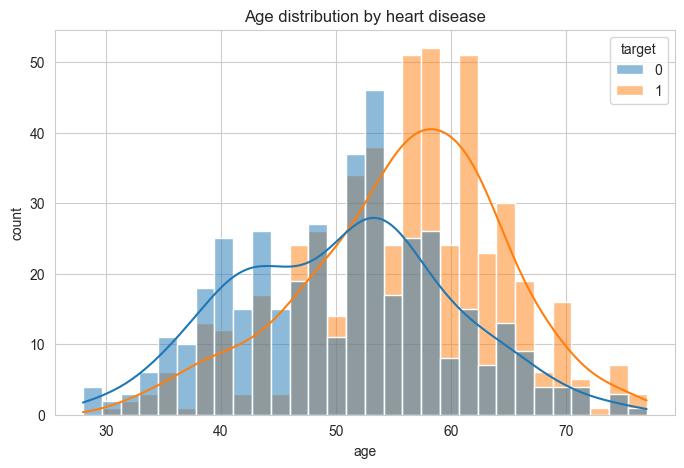

In [12]:
#Age vs Heart disease 
plt.figure(figsize=(8,5))
sns.histplot(data=data,x='age',hue='target',bins=30,kde=True)
plt.title('Age distribution by heart disease')
plt.xlabel('age')
plt.ylabel('count')
plt.show()


In [13]:
#Observation:Heart disease is more common in older people, particularly those between 55 and 65 years old. Younger individuals, especially under 40, are less likely to have it, showing that the risk increases with age.

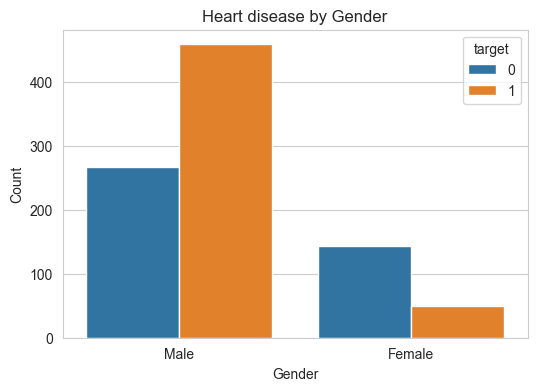

In [14]:
#Gender vs Heart disease
plt.figure(figsize=(6,4))
sns.countplot(data=data,x='sex',hue='target')
plt.title('Heart disease by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [15]:
#Observation: Heart disease seems to be more prevalent in males than females , as a larger number of male patients are affected 

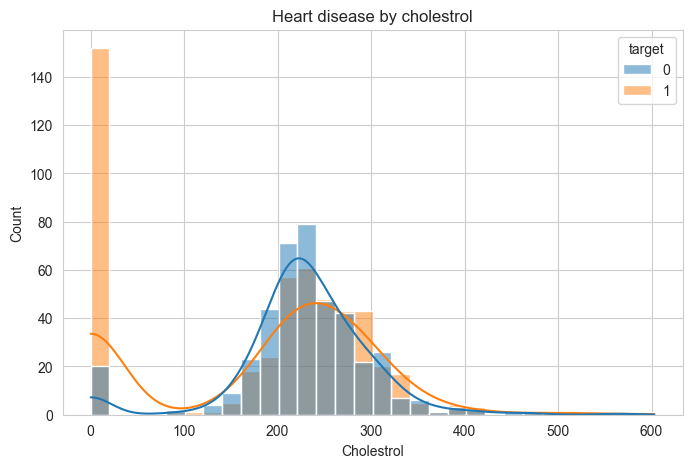

In [16]:
#cholestrol vs Heart disease 
plt.figure(figsize=(8,5))
sns.histplot(data=data,x='chol',hue='target',bins=30,kde=True)
plt.title('Heart disease by cholestrol')
plt.xlabel('Cholestrol')
plt.ylabel('Count')
plt.show()

In [17]:
#Observation:The distribution of cholesterol levels shows a significant overlap between individuals with and without heart disease. Most values fall between 150 and 300, with both groups following a similar pattern. Although there is a slight tendency for individuals with heart disease to have higher cholesterol levels, the difference is not very pronounced. This suggests that cholesterol alone may not be a strong predictor of heart disease in this dataset.(the spike at zero is most likely due to missing values being filled by zero)

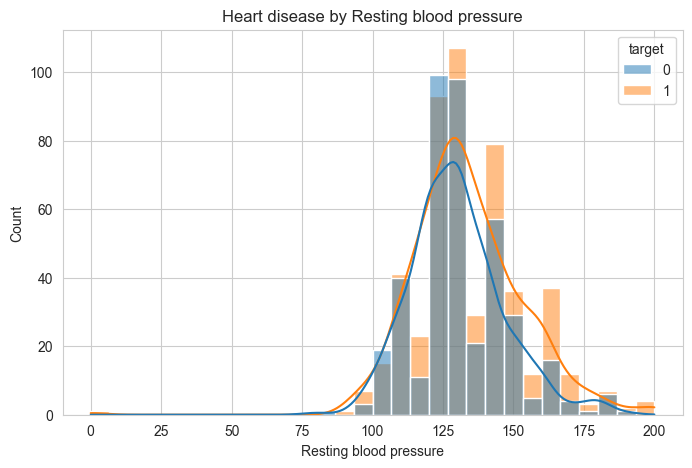

In [18]:
#Resting blood pressure vs Heart disease 
plt.figure(figsize=(8,5))
sns.histplot(data=data,x='trestbps',hue='target',bins=30,kde=True)
plt.title('Heart disease by Resting blood pressure')
plt.xlabel('Resting blood pressure')
plt.ylabel('Count')
plt.show()

In [19]:
#Observation:The resting blood pressure values for people with and without heart disease look quite similar, with most falling between 110 and 140 mm Hg. Although those with heart disease tend to have slightly higher values, especially above 140 mm Hg, the overall patterns overlap a lot. This suggests that resting blood pressure by itself may not be a very strong indicator of heart disease.

<Axes: >

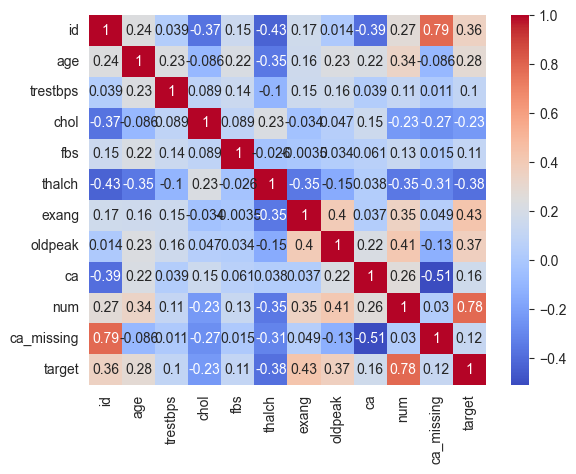

In [20]:
#Correlation Heatmap
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [21]:
data.columns



Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num',
       'ca_missing', 'target'],
      dtype='object')

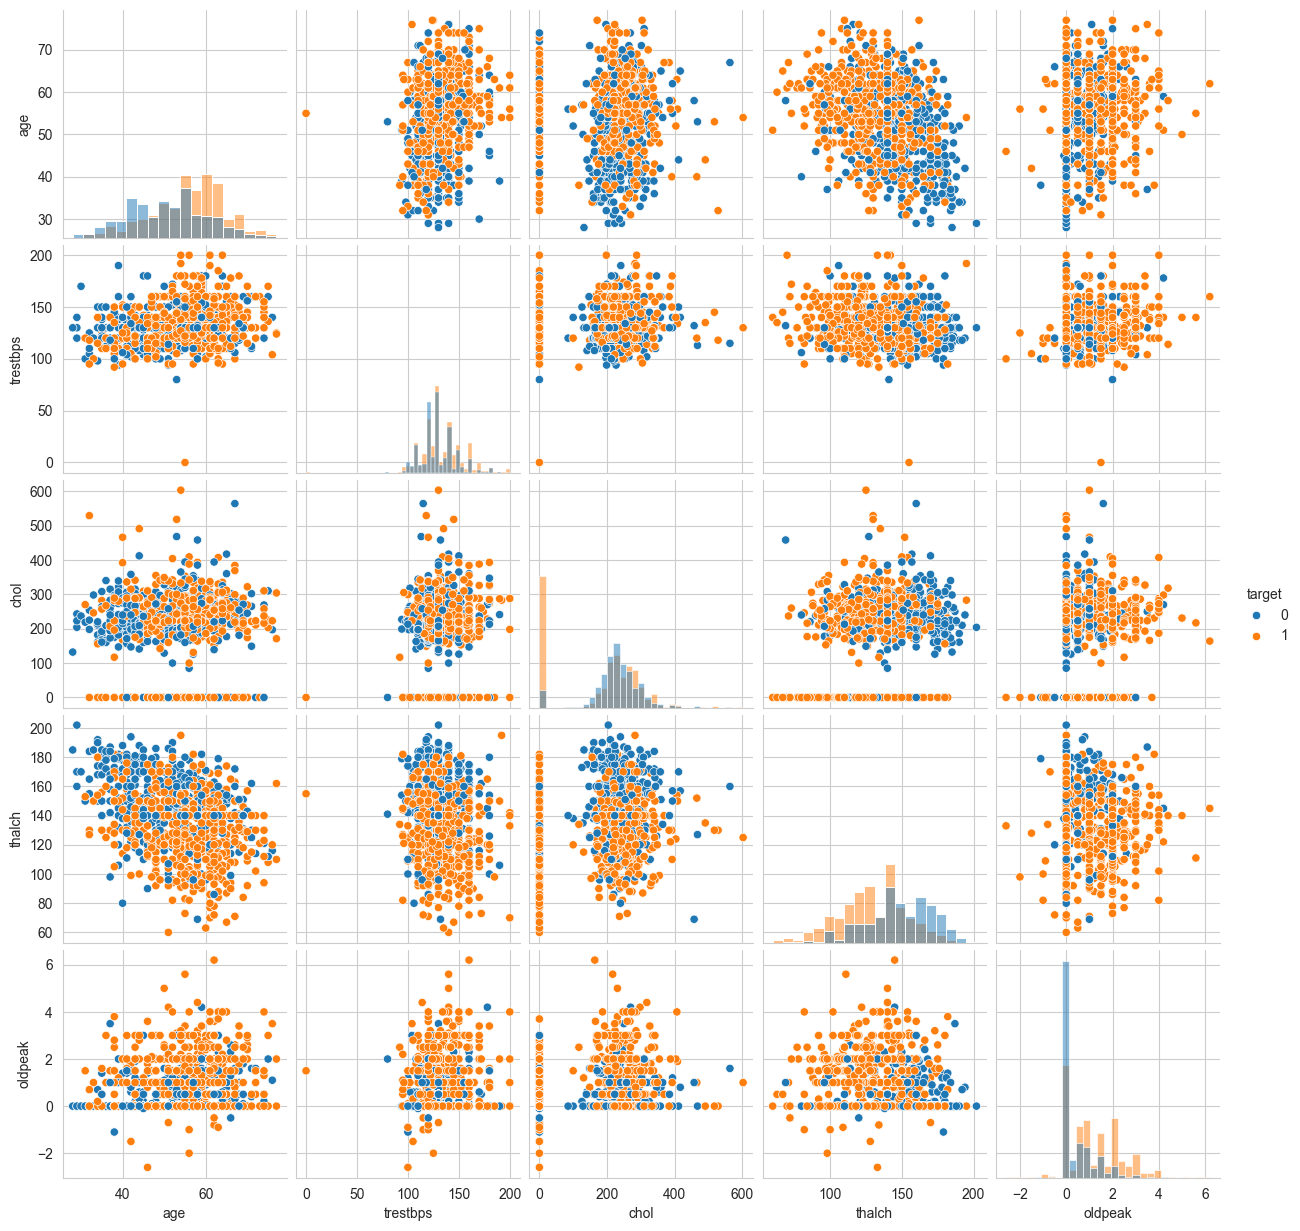

In [22]:
#MULTIVARIATE ANALYSIS 
sns.pairplot(
    data[['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'target']],
    hue='target',
    diag_kind='hist'
)

plt.show()

In [76]:
data.groupby('target')[['age','trestbps','chol','thalch','oldpeak']].mean() 

,age,trestbps,chol,thalch,oldpeak
target,,,,,
0,50.547445,129.917275,227.678832,148.372263,0.422384
1,55.903733,133.673870,177.485265,129.068762,1.201179


In [82]:
x = data.drop(columns=['id','num', 'target'])
y = data['target']


In [75]:
print(x.head())
print()
print(y.head())

   age  trestbps   chol    fbs  thalch  exang  oldpeak   ca  ca_missing  \
0   63     145.0  233.0   True   150.0  False      2.3  0.0           0   
1   67     160.0  286.0  False   108.0   True      1.5  3.0           0   
2   67     120.0  229.0  False   129.0   True      2.6  2.0           0   
3   37     130.0  250.0  False   187.0  False      3.5  0.0           0   
4   41     130.0  204.0  False   172.0  False      1.4  0.0           0   

   sex_Male  ...  dataset_VA Long Beach  cp_atypical angina  cp_non-anginal  \
0      True  ...                  False               False           False   
1      True  ...                  False               False           False   
2      True  ...                  False               False           False   
3      True  ...                  False               False            True   
4     False  ...                  False                True           False   

   cp_typical angina  restecg_normal  restecg_st-t abnormality  slope_flat

In [83]:

x = pd.get_dummies(x, drop_first=True)
y = pd.get_dummies(y, drop_first=True)
x = x.drop(columns=[
    "dataset_Hungary",
    "dataset_Switzerland",
    "dataset_VA Long Beach"
])



In [84]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [85]:
print('training features',x_train.shape)
print('testing features',x_test.shape)
print('training targets',y_train.shape)
print('testing targets',y_test.shape)

training features (736, 19)
testing features (184, 19)
training targets (736, 1)
testing targets (184, 1)


In [86]:
from sklearn.linear_model import LogisticRegression 

In [87]:
Heart_model=LogisticRegression(max_iter=1000)

In [88]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       920 non-null    int64  
 1   trestbps                  920 non-null    float64
 2   chol                      920 non-null    float64
 3   fbs                       920 non-null    bool   
 4   thalch                    920 non-null    float64
 5   exang                     920 non-null    bool   
 6   oldpeak                   920 non-null    float64
 7   ca                        920 non-null    float64
 8   ca_missing                920 non-null    int64  
 9   sex_Male                  920 non-null    bool   
 10  cp_atypical angina        920 non-null    bool   
 11  cp_non-anginal            920 non-null    bool   
 12  cp_typical angina         920 non-null    bool   
 13  restecg_normal            920 non-null    bool   
 14  restecg_st

In [89]:
print(type(y_train))
print(y_train.shape)

<class 'pandas.core.frame.DataFrame'>
(736, 1)


In [90]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [91]:
Heart_model.fit(x_train,y_train)

/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWar

LogisticRegression(max_iter=1000)

In [92]:
print(x_train.isnull().sum())

age                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
ca                          0
ca_missing                  0
sex_Male                    0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_normal              0
restecg_st-t abnormality    0
slope_flat                  0
slope_upsloping             0
thal_normal                 0
thal_reversable defect      0
dtype: int64


In [93]:
import numpy as np
print(np.isinf(x_train).sum())

age                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
ca                          0
ca_missing                  0
sex_Male                    0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_normal              0
restecg_st-t abnormality    0
slope_flat                  0
slope_upsloping             0
thal_normal                 0
thal_reversable defect      0
dtype: int64


In [94]:
print(x_train.columns)

Index(['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'ca',
       'ca_missing', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal',
       'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality',
       'slope_flat', 'slope_upsloping', 'thal_normal',
       'thal_reversable defect'],
      dtype='object')


In [95]:
print(x_train.dtypes)

age                           int64
trestbps                    float64
chol                        float64
fbs                            bool
thalch                      float64
exang                          bool
oldpeak                     float64
ca                          float64
ca_missing                    int64
sex_Male                       bool
cp_atypical angina             bool
cp_non-anginal                 bool
cp_typical angina              bool
restecg_normal                 bool
restecg_st-t abnormality       bool
slope_flat                     bool
slope_upsloping                bool
thal_normal                    bool
thal_reversable defect         bool
dtype: object


In [96]:
x_train.describe()
print(x_train["ca"].unique())
print(x_train["oldpeak"].describe())

[0. 3. 1. 2.]
count    736.000000
mean       0.857880
std        1.080636
min       -2.600000
25%        0.000000
50%        0.500000
75%        1.500000
max        6.200000
Name: oldpeak, dtype: float64


In [97]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Heart_model.fit(x_train_scaled, y_train)

/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWar

LogisticRegression(max_iter=1000)

In [98]:
print(y_train.squeeze().value_counts())

1
True     400
False    336
Name: count, dtype: int64


In [99]:
import numpy as np

print(np.isnan(x_train_scaled).sum())
print(np.isinf(x_train_scaled).sum())

0
0


In [100]:
print(x_train.var())

age                            85.132416
trestbps                      348.730255
chol                        11897.364949
fbs                             0.119543
thalch                        638.749956
exang                           0.231854
oldpeak                         1.167775
ca                              0.418781
ca_missing                      0.224601
sex_Male                        0.162489
cp_atypical angina              0.153400
cp_non-anginal                  0.172654
cp_typical angina               0.047809
restecg_normal                  0.241282
restecg_st-t abnormality        0.155923
slope_flat                      0.214624
slope_upsloping                 0.179326
thal_normal                     0.187073
thal_reversable defect          0.159235
dtype: float64


In [101]:
Heart_model = LogisticRegression(
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

Heart_model.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [102]:
print(x_train.shape)
print(x_test.shape)

print(x_train.columns.equals(x_test.columns))

print(x_train.columns.symmetric_difference(x_test.columns))
print(np.max(np.abs(x_train_scaled)))
print(np.max(np.abs(x_test_scaled)))

(736, 19)
(184, 19)
True
Index([], dtype='object')
7.0501116747540085
4.346480402796254


In [103]:
y_pred = Heart_model.predict(x_test_scaled)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7989130434782609


/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [104]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[60 15]
 [22 87]]
              precision    recall  f1-score   support

       False       0.73      0.80      0.76        75
        True       0.85      0.80      0.82       109

    accuracy                           0.80       184
   macro avg       0.79      0.80      0.79       184
weighted avg       0.80      0.80      0.80       184



In [105]:
Heart_model = LogisticRegression(
    solver="lbfgs",
    max_iter=5000,
    random_state=42)

In [106]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver="liblinear", random_state=42)

scores = cross_val_score(model, x_train_scaled, y_train, cv=5)

print(scores)
print(scores.mean())

[0.81756757 0.75510204 0.81632653 0.84353741 0.85714286]
0.8179352822209964


/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kishancarani/heart_disease_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

In [107]:
print(y_train.dtype)
print(y_test.dtype)

print(np.unique(y_train))
print(np.unique(y_test))

bool
bool
[False  True]
[False  True]


In [108]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
# Tuned
#rf = RandomForestClassifier(
    #n_estimators=500,
    #min_samples_leaf=2,
    #max_features='sqrt',
    #random_state=42)
#Accuracy dropped hence using untuned model because overfitting reduced but also ability to learn patterns reduced because the parameters chose made the trees less complex:
#max_depth=10 → trees cannot grow very deep.
#min_samples_leaf=2 → leaves need at least 2 samples.

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)


accuracy = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy)


print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


scores = cross_val_score(
    rf,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(scores)
print("Mean Accuracy:", scores.mean())

Accuracy: 0.8641304347826086
[[65 10]
 [15 94]]
              precision    recall  f1-score   support

       False       0.81      0.87      0.84        75
        True       0.90      0.86      0.88       109

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184

[0.78378378 0.7755102  0.80272109 0.79591837 0.85714286]
Mean Accuracy: 0.8030152601581172


In [109]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

print(importance)

                     Feature  Importance
2                       chol    0.138458
4                     thalch    0.133014
6                    oldpeak    0.117784
0                        age    0.104776
5                      exang    0.086593
1                   trestbps    0.080476
10        cp_atypical angina    0.069420
9                   sex_Male    0.055897
11            cp_non-anginal    0.031556
7                         ca    0.029839
17               thal_normal    0.028846
8                 ca_missing    0.017417
3                        fbs    0.016281
13            restecg_normal    0.016242
18    thal_reversable defect    0.016055
12         cp_typical angina    0.016011
16           slope_upsloping    0.014203
15                slope_flat    0.013779
14  restecg_st-t abnormality    0.013352


<function matplotlib.pyplot.show(close=None, block=None)>

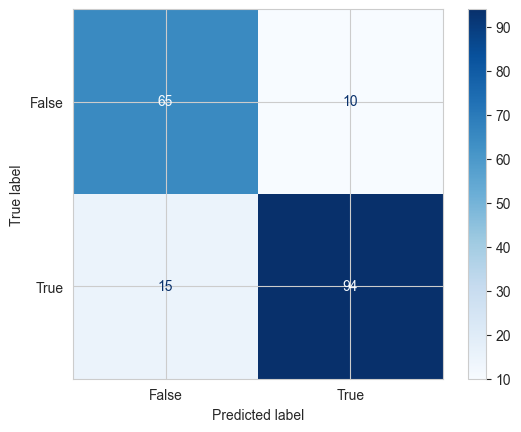

In [110]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    x_test,
    y_test,
    cmap="Blues"
)

plt.show

In [111]:
import joblib

joblib.dump(rf, "../model/heart_disease_model.pkl")

['../model/heart_disease_model.pkl']

In [112]:
print(x_train.columns.tolist())

['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'ca', 'ca_missing', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect']
